<a href="https://colab.research.google.com/github/tapiaj-git/DS201Cap1/blob/main/DSCap1v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting into Business: Real Estate Investment Data Exploration

**Authors:** John Tapia, Jacob Dudas, James Pfaff

This notebook explores the Federal Housing Finance Agency (FHFA) House Price Index (HPI) dataset to understand its coverage, attributes, and housing price trends.


## 1. Understanding the Data

### Load the FHFA data and its data dictionary


In [ ]:
!wget "https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv"

--2026-09-28 23:38:25--  https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv
Resolving www.fhfa.gov (www.fhfa.gov)... 54.92.167.213
Connecting to www.fhfa.gov (www.fhfa.gov)|54.92.167.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17154972 (16M) [text/csv]
Saving to: ‘hpi_master.csv’

hpi_master.csv      100%[===================>]  16.36M  22.6MB/s    in 0.7s    

2026-09-28 23:38:27 (22.6 MB/s) - ‘hpi_master.csv’ saved [17154972/17154972]



In [ ]:
import pandas as pd
import numpy as np

url = "https://www.fhfa.gov/document/d/hpi/hpi_dictionary.xlsx"
df_def = pd.read_excel(url, sheet_name='Dictionary', header=1)

df_def.loc[8, 'Description'] = 'House Price Index, not seasonally adjusted. Measures changes in house prices without removing seasonal patterns.'

df_def.loc[9, 'Description'] = 'House Price Index, seasonally adjusted. Measures changes in house prices after removing seasonal patterns to make periods easier to compare.'

df_def

,Column,Field Name,Content,Type,Length,Example Values,Description
0,1,hpi_type,type of data,string,13,"traditional, developmental, distress-free, non...","The traditional, purchase-only, seasonally adj..."
1,2,hpi_flavor,flavor of HPI,string,16,"purchase-only, all-transactions, expanded-data",These are the three main types of FHFA HPIs an...
2,3,frequency,frequency of data,string,9,"monthly, quarterly",The only indexes produced on a monthly basis a...
3,4,level,level of geography,string,22,"USA or Census Division, State, MSA, Puerto Rico",The MSA is the lowest level of geography.
4,5,place_name,place name,string,57,"East North Central Division; Alabama; Abilene, TX",Traditional names.
5,6,place_id,place ID,string,6,"AK, 10180, DV_ENC, PR",Abbreviations or CBSA codes.
6,7,yr,year,numeric,4,"1975, 2000, 2013",Only the all-transactions data are published b...
7,8,period,period,numeric,2,"1, 10, 12",Period is either 1 through 4 for quarterly or ...
8,9,index_nsa,"index, non seasonally adjusted",numeric,6,"100.00, 79.05, 370.65","House Price Index, not seasonally adjusted. Me..."
9,10,index_sa,"index, seasonally adjusted",numeric,6,"100.00, 79.05, 370.65","House Price Index, seasonally adjusted. Measur..."


In [ ]:
from pathlib import Path


relative_path = Path("hpi_master.csv")

df = pd.read_csv(relative_path)
df

/tmp/ipykernel_1169/3197980960.py:6: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(relative_path)


,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa,rstderr,note
0,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,1,100.00,100.00,NaN,NaN
1,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,2,100.87,100.87,NaN,NaN
2,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,3,101.32,100.90,NaN,NaN
3,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,4,101.73,100.96,NaN,NaN
4,traditional,purchase-only,monthly,USA or Census Division,East North Central Division,DV_ENC,1991,5,102.32,101.31,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
186006,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2025,2,253.46,255.52,NaN,NaN
186007,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2025,3,243.73,239.74,NaN,NaN
186008,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2025,4,248.37,251.78,NaN,NaN
186009,developmental,purchase-only,quarterly,Puerto Rico,Puerto Rico,PR,2026,1,272.77,272.95,NaN,NaN


### When was the data acquired?


After getting the relative path of the csv file, I named it df. I opened the df and can see that the data ranges from 1975 to 2026. The FHFA publishes releases monthly and quarterly. It combines current and historical data.

### Where was the data acquired?


This data was aquired in the United States as a whole. Specifically, this data is divided up between the 9 U.S Census Divisions, individual U.S states, the Metropolitan area, and Puerto Rico.

### How was the data acquired?


The FHFA House Price Index tracks changes in single-family home prices over time. It uses real mortgage and housing transactions. FHFA gets mortgage information from Fannie Mae and Freddie Mac, government sponsored companies. It looks at homes that were sold or refinanced more than once and compares the prices from each transaction. This helps show how home values changed over time. The data has been collected since 1975 and is considered observational data because it comes from real housing transactions. The HPI is basically measuring how much home prices have changed over time.

### What are the attributes of this dataset?


In [ ]:
df_def.loc[df_def["Field Name"] == "index_nsa", "Description"] = (
    "House Price Index values that are not adjusted for seasonal patterns."
)

df_def.loc[df_def["Field Name"] == "index_sa", "Description"] = (
    "House Price Index values adjusted to remove seasonal patterns."
)

df_def

,Column,Field Name,Content,Type,Length,Example Values,Description
0,1,hpi_type,type of data,string,13,"traditional, developmental, distress-free, non...","The traditional, purchase-only, seasonally adj..."
1,2,hpi_flavor,flavor of HPI,string,16,"purchase-only, all-transactions, expanded-data",These are the three main types of FHFA HPIs an...
2,3,frequency,frequency of data,string,9,"monthly, quarterly",The only indexes produced on a monthly basis a...
3,4,level,level of geography,string,22,"USA or Census Division, State, MSA, Puerto Rico",The MSA is the lowest level of geography.
4,5,place_name,place name,string,57,"East North Central Division; Alabama; Abilene, TX",Traditional names.
5,6,place_id,place ID,string,6,"AK, 10180, DV_ENC, PR",Abbreviations or CBSA codes.
6,7,yr,year,numeric,4,"1975, 2000, 2013",Only the all-transactions data are published b...
7,8,period,period,numeric,2,"1, 10, 12",Period is either 1 through 4 for quarterly or ...
8,9,index_nsa,"index, non seasonally adjusted",numeric,6,"100.00, 79.05, 370.65",House Price Index values that are not adjusted...
9,10,index_sa,"index, seasonally adjusted",numeric,6,"100.00, 79.05, 370.65",House Price Index values adjusted to remove se...


### What types of data do the attributes contain?


In [ ]:
def get_measurement_type(column_name, series):

    if column_name == "yr":
        return "Interval"

    elif column_name == "period":
        return "Ordinal"

    elif column_name.startswith("index_"):
        return "Interval"

    elif pd.api.types.is_numeric_dtype(series):
        return "Ratio"

    else:
        return "Nominal"


data_types_table = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": [
        get_measurement_type(column, df[column])
        for column in df.columns
    ]
})

data_types_table

,Column Name,Data Type
0,hpi_type,Nominal
1,hpi_flavor,Nominal
2,frequency,Nominal
3,level,Nominal
4,place_name,Nominal
5,place_id,Nominal
6,yr,Interval
7,period,Ordinal
8,index_nsa,Interval
9,index_sa,Interval


The columns hpi_type, hpi_flavor, frequency, level, place_name, place_id, and note are nominal because they are categories with no numerical value. The period column is ordinal because the months or quarters follow an order, while yr is interval because the difference between years is important but there is no true year zero. The index_nsa and index_sa columns are interval because they show changes from a base index value of 100, and rstderr is ratio because zero represents no standard error and the values can be compared.

## 2. Data Summary and Initial Insights

### Check and clean missing or empty values


In [ ]:
df['note'].unique()

array([nan,
       'Note: Fewer than 1,000 repeat-sales records have accumulated up to this quarter',
       '\t',
       'Note: Index value suppressed due to too few repeat-sales records in the sample for this quarter'],
      dtype=object)

In [ ]:

df['note'] = df['note'].str.replace('\t', '', regex=False)
df['note'] = df['note'].replace('', np.nan)
df['note'].unique()

array([nan,
       'Note: Fewer than 1,000 repeat-sales records have accumulated up to this quarter',
       'Note: Index value suppressed due to too few repeat-sales records in the sample for this quarter'],
      dtype=object)

In [ ]:
df['note'].value_counts(dropna=False).head(20)

,count
note,
NaN,185560
"Note: Fewer than 1,000 repeat-sales records have accumulated up to this quarter",449
Note: Index value suppressed due to too few repeat-sales records in the sample for this quarter,2


In [ ]:
df.isna().sum()

,0
hpi_type,0
hpi_flavor,0
frequency,0
level,0
place_name,0
place_id,0
yr,0
period,0
index_nsa,0
index_sa,89897


The dataset has missing values in index_sa, rstderr, and note. Missing values in note usually mean there is no special note for that obeservation, so they do not need to be removed. For analyses that require seasonally adjusted values or relative standard errors, I would use only the rows where the needed column has a value instead of deleting all rows with missing data.

### Summary statistics


In [ ]:
print("Descriptive statistics for Interval and Ratio columns:")
display(df[['yr', 'index_nsa', 'index_sa', 'rstderr']].describe())

print("\nDescriptive statistics for Nominal columns:")
display(df.describe(include='object'))

print("\nFrequency distribution for 'period' (Ordinal) column:")
print(df['period'].value_counts().sort_index().to_string())

Descriptive statistics for Interval and Ratio columns:


,yr,index_nsa,index_sa,rstderr
count,186011.000000,186011.000000,96114.000000,58220.000000
mean,2006.159926,199.962128,216.670407,2.673249
std,12.004355,116.125443,113.512712,2.222155
min,1975.000000,18.600000,72.780000,0.000000
25%,1997.000000,119.610000,137.290000,1.060000
50%,2007.000000,172.130000,187.210000,2.050000
75%,2016.000000,241.380000,258.337500,3.600000
max,2026.000000,1326.940000,1043.200000,15.750000



Descriptive statistics for Nominal columns:


,hpi_type,hpi_flavor,frequency,level,place_name,place_id,note
count,186011,186011,186011,186011,186011,186011,451
unique,5,3,2,4,472,472,2
top,traditional,all-transactions,quarterly,MSA,United States,USA,"Note: Fewer than 1,000 repeat-sales records ha..."
freq,177642,89791,181751,145480,1128,1128,449



Frequency distribution for 'period' (Ordinal) column:
period
1     46204
2     46337
3     45291
4     45359
5       360
6       360
7       350
8       350
9       350
10      350
11      350
12      350


### Housing price trends and distributions


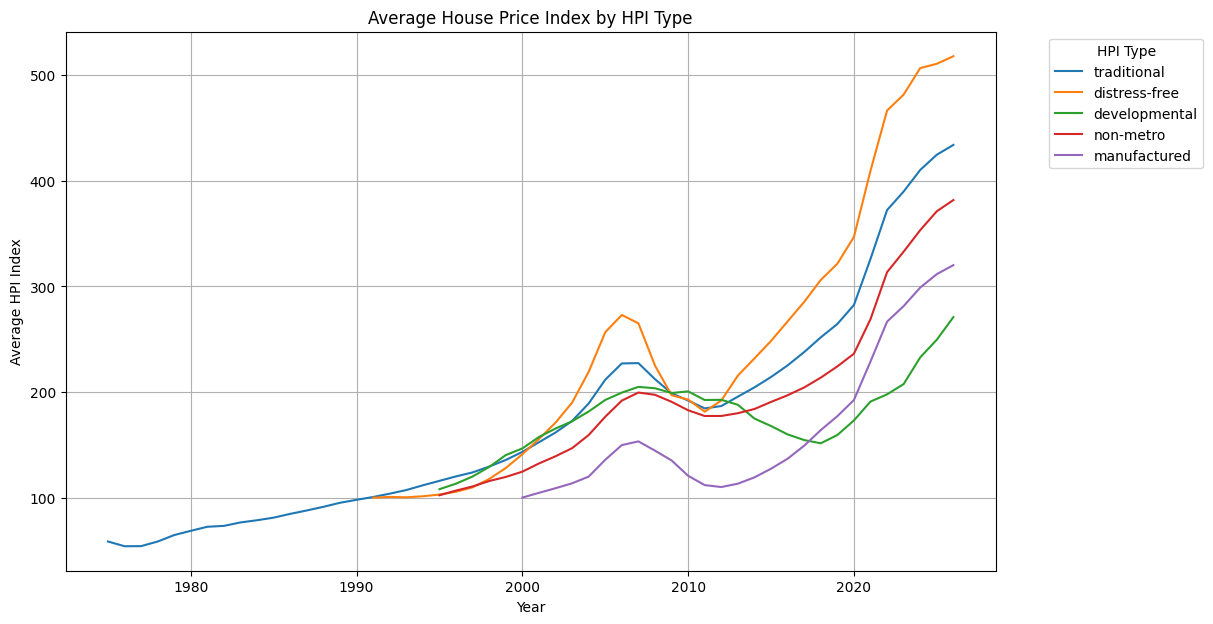

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

yearly_type = df.groupby(['yr', 'hpi_type'])['index_nsa'].mean().reset_index()

plt.figure(figsize=(12, 7))

for hpi_type in yearly_type['hpi_type'].unique():
    data = yearly_type[yearly_type['hpi_type'] == hpi_type]
    plt.plot(data['yr'], data['index_nsa'], label=hpi_type)

plt.xlabel('Year')
plt.ylabel('Average HPI Index')
plt.title('Average House Price Index by HPI Type')
plt.legend(title='HPI Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

This graph is useful for developing investment strategies because it shows how different types of housing have changed in value over time. By comparing categories such as traditional, distress-free, developmental, non-metro, and manufactured housing, investors can identify differences in long-term price growth and periods of decline or recovery. These trends can help investors understand which segments have historically experienced stronger appreciation and which have followed different market patterns. Using this information alongside other factors such as location, risk, and investment costs can help investors develop strategies that match their goals and determine which types of housing markets may be worth investigating further.

In [ ]:
# Keep only state-level records with an HPI value
state_data = df[
    df["level"].astype(str).str.strip().eq("State")
].dropna(subset=["index_nsa"]).copy()

# Select one consistent HPI series
series_columns = ["hpi_type", "hpi_flavor", "frequency"]

selected_series = (
    state_data.groupby(series_columns)
    .size()
    .idxmax()
)

for column, value in zip(series_columns, selected_series):
    state_data = state_data[state_data[column] == value]

# Average periods within each year for each state
yearly_state_hpi = (
    state_data.groupby(["place_name", "yr"], as_index=False)["index_nsa"]
    .mean()
)

yearly_state_hpi.head()

,place_name,yr,index_nsa
0,Alabama,1975,72.7450
1,Alabama,1976,76.7800
2,Alabama,1977,85.1975
3,Alabama,1978,91.9675
4,Alabama,1979,102.0475


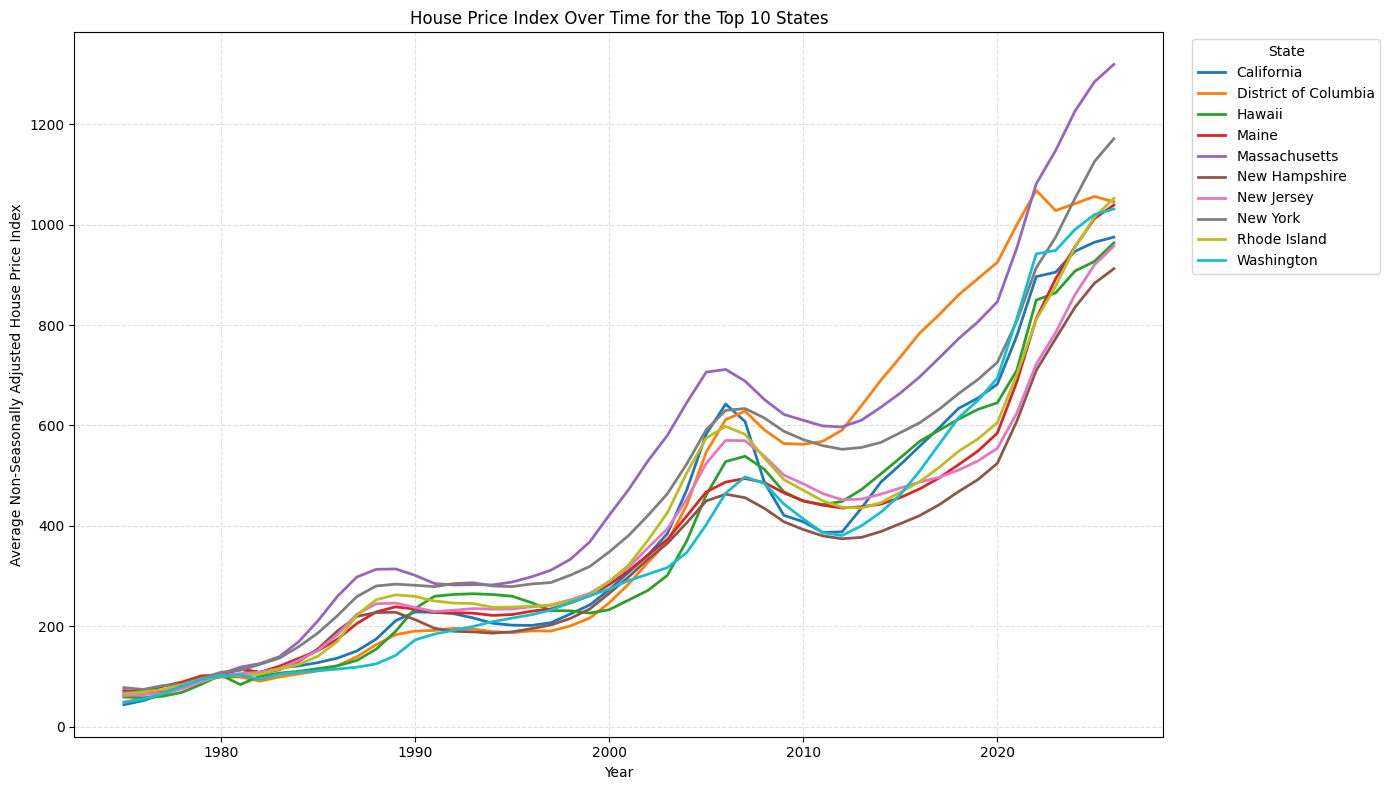

In [ ]:
latest_hpi = (
    yearly_state_hpi
    .sort_values("yr")
    .groupby("place_name")
    .tail(1)
)

top_10_states = latest_hpi.nlargest(10, "index_nsa")["place_name"]

top_10_data = yearly_state_hpi[
    yearly_state_hpi["place_name"].isin(top_10_states)
]


plt.figure(figsize=(14, 8))

for state, state_values in top_10_data.groupby("place_name"):
    plt.plot(
        state_values["yr"],
        state_values["index_nsa"],
        linewidth=2,
        label=state
    )

plt.title("House Price Index Over Time for the Top 10 States")
plt.xlabel("Year")
plt.ylabel("Average Non-Seasonally Adjusted House Price Index")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

The first line graph shows how the House Price Index changed over time for all observations in the dataset. For the most part it has just incrased, with 2008 being the exception due to the financial crisis.

The second graph looks on the 10 states with the highest recent House Price Index values. These states have had larger overall increases from their starting index values, but this does not mean they have the highest home prices or are the best places to invest. Investors should also look at other things before making a decision

## 3. Expanding Your Investment Knowledge

*Add an additional real estate dataset here, its link, why it is useful, and how it complements the FHFA HPI data.*

"All Counties": https://www.fema.gov/about/openfema/data-sets/national-risk-index-data


In [ ]:
import os
import zipfile

!wget -O NRI_Table_Counties.zip "https://www.fema.gov/about/reports-and-data/openfema/nri/v120/NRI_Table_Counties.zip"

with zipfile.ZipFile("NRI_Table_Counties.zip", "r") as zip_ref:
    zip_ref.extractall("nri_data")

cols_to_keep = [
    'STCOFIPS', 'STATE', 'STATEABBRV', 'COUNTY',
    'POPULATION', 'BUILDVALUE',
    'RISK_SCORE', 'RISK_RATNG', 'EAL_SCORE', 'EAL_VALB',
    'CFLD_EALB', 'WFIR_EALB', 'HRCN_EALB'
]

csv_path = os.path.join("nri_data", "NRI_Table_Counties.csv")
df_nri = pd.read_csv(csv_path, usecols=cols_to_keep)

df_nri['STCOFIPS'] = df_nri['STCOFIPS'].astype(str).str.zfill(5)
df_nri.head()

--2026-09-28 23:38:35--  https://www.fema.gov/about/reports-and-data/openfema/nri/v120/NRI_Table_Counties.zip
Resolving www.fema.gov (www.fema.gov)... 184.24.149.162, 2600:1409:9800:a8c::1955, 2600:1409:9800:a81::1955
Connecting to www.fema.gov (www.fema.gov)|184.24.149.162|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24966535 (24M) [application/zip]
Saving to: ‘NRI_Table_Counties.zip’

NRI_Table_Counties. 100%[===================>]  23.81M  31.7MB/s    in 0.8s    

2026-09-28 23:38:38 (31.7 MB/s) - ‘NRI_Table_Counties.zip’ saved [24966535/24966535]



,STATE,STATEABBRV,COUNTY,STCOFIPS,POPULATION,BUILDVALUE,RISK_SCORE,RISK_RATNG,EAL_SCORE,EAL_VALB,CFLD_EALB,HRCN_EALB,WFIR_EALB
0,Alabama,AL,Autauga,01001,58764,1.024141e+10,57.569975,Relatively Low,59.870050,1.385350e+07,NaN,6.335911e+05,3.002976e+04
1,Alabama,AL,Baldwin,01003,231365,5.160230e+10,96.723919,Relatively High,96.627475,2.084471e+08,3.704943e+06,1.508990e+08,1.282742e+06
2,Alabama,AL,Barbour,01005,25160,5.441822e+09,48.123410,Relatively Low,30.538366,5.555196e+06,NaN,6.121083e+05,2.161196e+04
3,Alabama,AL,Bibb,01007,22239,3.532631e+09,39.122137,Very Low,31.002475,6.128569e+06,NaN,4.383745e+04,2.579498e+04
4,Alabama,AL,Blount,01009,58992,8.773489e+09,68.479644,Relatively Low,62.345297,1.336903e+07,NaN,4.263647e+04,7.351167e+04





1. Why This Dataset Is Useful

The FEMA National Risk Index provides metrics quantifying natural hazard and financial vulnerability for every U.S. county. It bundles up properties by county. Key metrics in the dataset include:



*   Expected Annual Loss for Buildings (EAL_VALB): Measures the average annual dollar loss caused by damage to residential and commercial structures from natural hazards.


*  Hazard-Specific Building Losses (CFLD_EALB, HRCN_EALB, WFIR_EALB): Breaks down annual structural damage specifically for coastal flooding, hurricanes, wildfires, and other natural hazards.



*  Composite Risk Score & Rating (RISK_SCORE, RISK_RATNG):  Its a disaster risk score/rating relative to all other U.S. counties from 0–100. For a real estate investors, these variables provides physical risk, maintenance/rebuilding costs and long-term asset preservation across these markets.

2. How It Complements the FHFA HPI Dataset


While the FHFA House Price Index provides important time-series tracking of property value appreciation across regions, FEMA's data highlights the dangers of natural disasters. Cross-referencing that county's high risk scores reveals  hidden holding costs such as insurance premiums, flood insurance, and rebuilding costs.


## 4. Communicating Your Findings


This analysis used FHFA House Price Index data to look at housing price changes across the United States over time. Overall, the graphs show that home values have increased in many states, but the amount of growth is different depending on the location. The HPI measures changes in prices, not the actual dollar price of a home, so it can help investors compare trends. The FEMA National Risk Index can also help investors consider risks such as flooding, hurricanes, and wildfires before choosing where to invest.